<a href="https://colab.research.google.com/github/osamamohamaed/Myprojects/blob/main/big_market.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

In [ ]:
df=pd.read_csv('/content/Train.csv')
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
df.shape

(8523, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [ ]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [ ]:
df['Item_Weight'].mean()

np.float64(12.857645184135976)

In [ ]:
df['Item_Weight'].fillna(df['Item_Weight'].mean , inplace=True )


/tmp/ipython-input-1053466687.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '<bound method Series.mean of 0        9.300
1        5.920
2       17.500
3       19.200
4        8.930
         ...  
8518     6.865
8519     8.380
8520    10.600
8521     7.210
8522    14.800
Name: Item_Weight, Length: 8523, dtype: float64>' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df['Item_Weight'].fillna(df['Item_Weight'].mean , inplace=True )


array([9.3, 5.92, 17.5, 19.2, 8.93, 10.395, 13.65,
       <bound method Series.mean of 0        9.300
       1        5.920
       2       17.500
       3       19.200
       4        8.930
                ...
       8518     6.865
       8519     8.380
       8520    10.600
       8521     7.210
       8522    14.800
       Name: Item_Weight, Length: 8523, dtype: float64>, 16.2, 11.8, 18.5,
       15.1, 17.6, 16.35, 9.0, 13.35, 18.85, 14.6, 13.85, 13.0, 7.645,
       11.65, 5.925, 19.25, 18.6, 18.7, 17.85, 10.0, 8.85, 9.8, 13.6,
       21.35, 12.15, 6.42, 19.6, 15.85, 7.39, 10.195, 9.895, 10.895,
       7.905, 9.195, 8.365, 7.97, 17.7, 19.35, 8.645, 15.6, 18.25, 7.855,
       7.825, 8.39, 12.85, 19.0, 5.905, 7.76, 16.75, 15.5, 6.055, 6.305,
       20.85, 20.75, 8.895, 19.7, 8.75, 13.3, 8.31, 19.75, 17.1, 10.5,
       6.635, 14.15, 8.89, 9.1, 7.5, 16.85, 7.485, 11.6, 12.65, 20.25,
       8.6, 12.6, 8.88, 20.5, 13.5, 7.235, 6.92, 8.02, 12.8, 16.6, 14.0,
       16.0, 21.25, 7.365, 18.35,

In [ ]:
df['Item_Weight'].isnull()

,Item_Weight
0,False
1,False
2,False
3,False
4,False
...,...
8518,False
8519,False
8520,False
8521,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   object 
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
 12  new_weight                 8523 non-null   object 
dtypes: float64(3), int64(1), object(9)
memory usage:

In [ ]:
df['Outlet_Size'].unique()



array(['Medium', nan, 'High', 'Small'], dtype=object)

In [ ]:
df['Outlet_Size'].mode()


,Outlet_Size
0,Medium


In [ ]:
mode_of_seals=df.pivot_table(
    values='Outlet_Size',
    columns='Outlet_Type',
    aggfunc=(lambda x: x.mode()[0])
)
print(mode_of_seals)

Outlet_Type Grocery Store Supermarket Type1 Supermarket Type2  \
Outlet_Size         Small             Small            Medium   

Outlet_Type Supermarket Type3  
Outlet_Size            Medium  


In [ ]:
miss_values = df['Outlet_Size'].isnull()
print(miss_values)

0       False
1       False
2       False
3        True
4       False
        ...  
8518    False
8519     True
8520    False
8521    False
8522    False
Name: Outlet_Size, Length: 8523, dtype: bool


In [ ]:
df.loc[miss_values,'Outlet_Size']=df.loc[miss_values,'Outlet_Type'].apply(lambda x : mode_of_seals[x])


In [ ]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [ ]:
df.describe()

,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000
mean,0.066132,140.992782,1997.831867,2181.288914
std,0.051598,62.275067,8.371760,1706.499616
min,0.000000,31.290000,1985.000000,33.290000
25%,0.026989,93.826500,1987.000000,834.247400
50%,0.053931,143.012800,1999.000000,1794.331000
75%,0.094585,185.643700,2004.000000,3101.296400
max,0.328391,266.888400,2009.000000,13086.964800


In [ ]:
sns.set()

/tmp/ipython-input-1745525419.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Item_Visibility'])


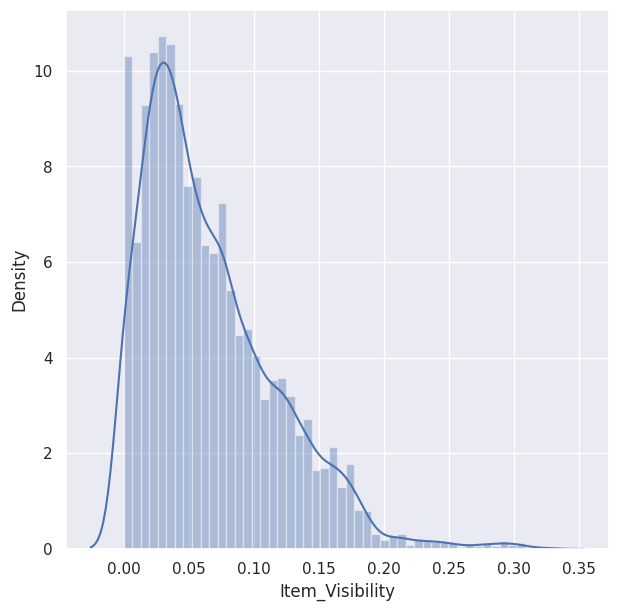

In [ ]:
plt.figure(figsize=(7,7))
sns.distplot(df['Item_Visibility'])
plt.show()

/tmp/ipython-input-863441351.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Item_MRP'])


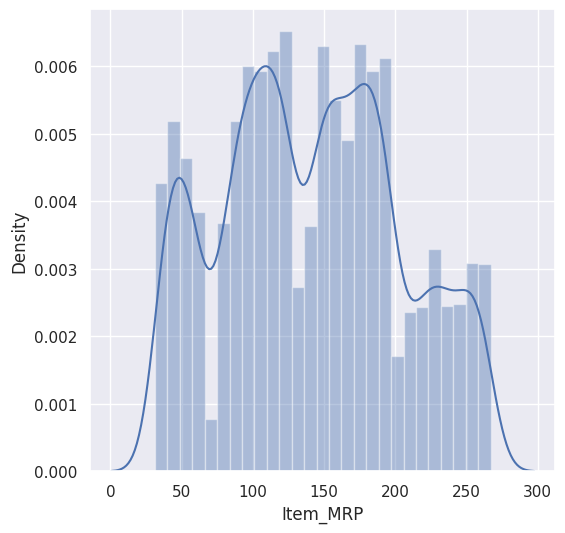

In [ ]:
plt.figure(figsize=(6,6))
sns.distplot(df['Item_MRP'])
plt.show()

/tmp/ipython-input-616535255.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Item_Outlet_Sales'])


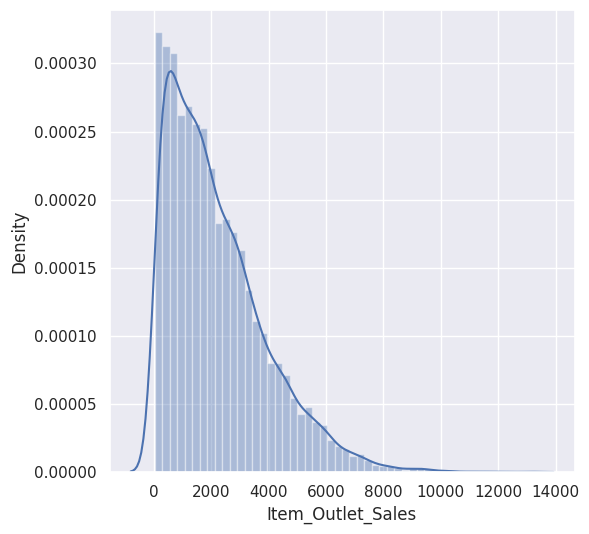

In [ ]:
plt.figure(figsize=(6,6))
sns.distplot(df['Item_Outlet_Sales'])
plt.show()

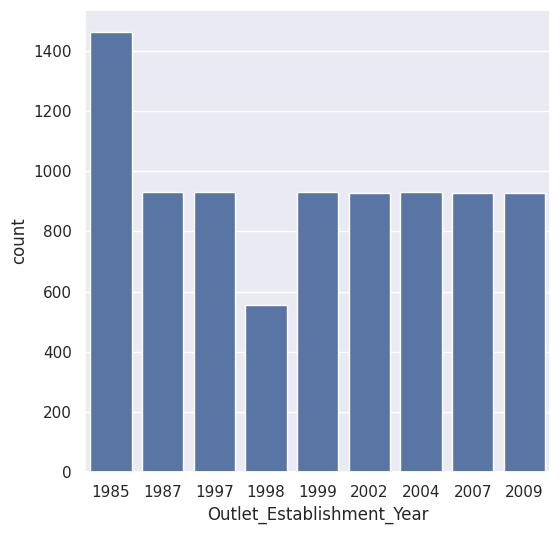

In [ ]:
plt.figure(figsize=(6,6))
sns.countplot(x='Outlet_Establishment_Year', data=df)
plt.show()

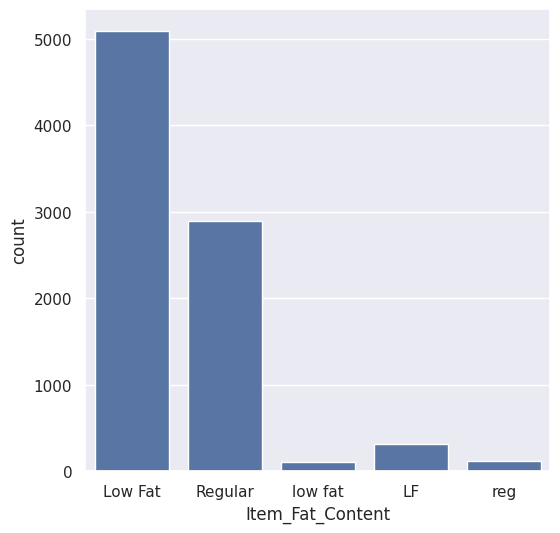

In [ ]:
plt.figure(figsize=(6,6))
sns.countplot(x='Item_Fat_Content', data=df)
plt.show()

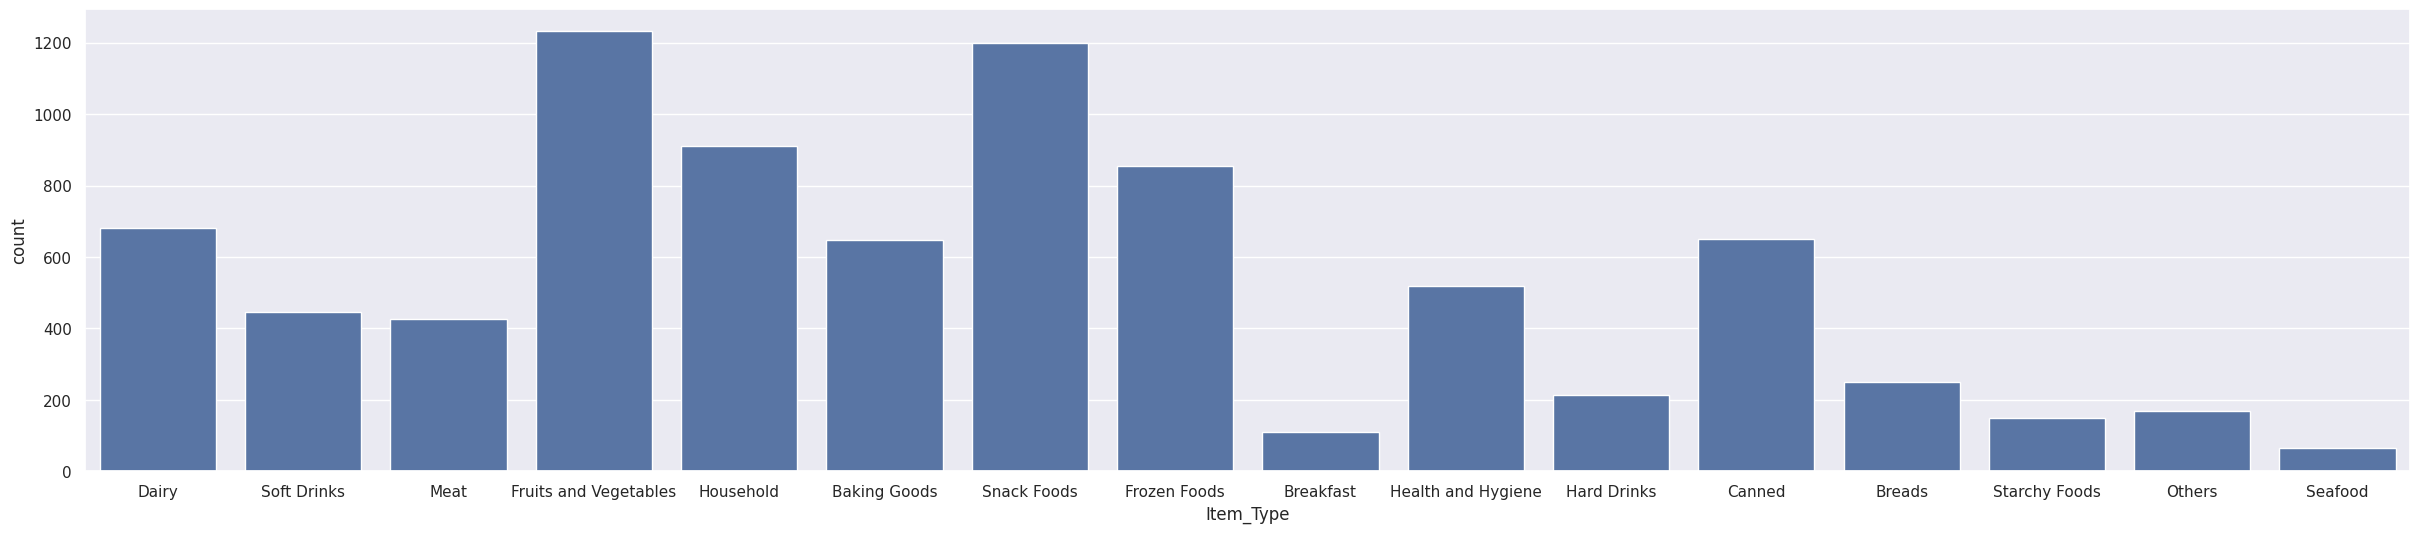

In [ ]:
plt.figure(figsize=(30,6))
sns.countplot(x='Item_Type', data=df)
plt.show()

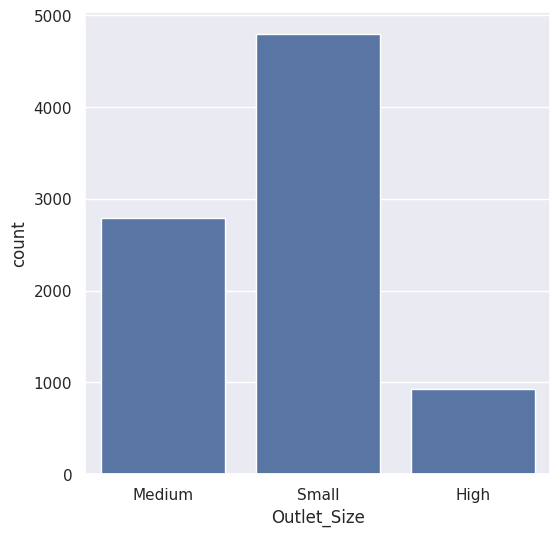

In [ ]:
plt.figure(figsize=(6,6))
sns.countplot(x='Outlet_Size', data=df)
plt.show()

In [ ]:
df.replace({'Item_Fat_Content': {'low fat':'Low Fat','LF':'Low Fat', 'reg':'Regular'}}, inplace=True)

In [ ]:
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


In [ ]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,new_weight
0,FDA15,9.3,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,9.3
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,5.92
2,FDN15,17.5,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,17.5
3,FDX07,19.2,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800,19.2
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,8.93


In [ ]:
encoder=LabelEncoder()

In [ ]:
df['Item_Identifier']=encoder.fit_transform(df['Item_Identifier'])
df['Item_Fat_Content']=encoder.fit_transform(df['Item_Fat_Content'])
df['Item_Type']=encoder.fit_transform(df['Item_Type'])
df['Outlet_Identifier']=encoder.fit_transform(df['Outlet_Identifier'])
df['Outlet_Size']=encoder.fit_transform(df['Outlet_Size'])
df['Outlet_Location_Type']=encoder.fit_transform(df['Outlet_Location_Type'])
df['Outlet_Type']=encoder.fit_transform(df['Outlet_Type'])


In [ ]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,new_weight
0,156,9.3,0,0.016047,4,249.8092,9,1999,1,0,1,3735.1380,9.3
1,8,5.92,1,0.019278,14,48.2692,3,2009,1,2,2,443.4228,5.92
2,662,17.5,0,0.016760,10,141.6180,9,1999,1,0,1,2097.2700,17.5
3,1121,19.2,1,0.000000,6,182.0950,0,1998,2,2,0,732.3800,19.2
4,1297,8.93,0,0.000000,9,53.8614,1,1987,0,2,1,994.7052,8.93


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   int64  
 1   Item_Weight                8523 non-null   object 
 2   Item_Fat_Content           8523 non-null   int64  
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   int64  
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   int64  
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   int64  
 9   Outlet_Location_Type       8523 non-null   int64  
 10  Outlet_Type                8523 non-null   int64  
 11  Item_Outlet_Sales          8523 non-null   float64
 12  new_weight                 8523 non-null   object 
dtypes: float64(3), int64(8), object(2)
memory usage:

In [ ]:
df.drop(columns=['new_weight'], inplace=True)

In [ ]:
fetuer = df.drop(columns='Item_Outlet_Sales', ,axis=1)
target = df['Item_Outlet_Sales']

In [ ]:
X_train , X_test, y_train,y_test=train_test_split(fetuer, target ,test_size=0.2    ,random_state=42)

In [ ]:
xgb_model = XGBRegressor()

In [ ]:

X_train['Item_Weight'] = pd.to_numeric(X_train['Item_Weight'], errors='coerce')
X_test['Item_Weight'] = pd.to_numeric(X_test['Item_Weight'], errors='coerce')

mean_item_weight_train = X_train['Item_Weight'].mean()

X_train['Item_Weight'].fillna(mean_item_weight_train, inplace=True)
X_test['Item_Weight'].fillna(mean_item_weight_train, inplace=True)

#xgb_model= XGBRegressor(objective='reg:squarederror', n_estimators=2000, random_state=42)
xgb_model.fit(X_train, y_train)

/tmp/ipython-input-518514283.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train['Item_Weight'].fillna(mean_item_weight_train, inplace=True)
/tmp/ipython-input-518514283.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
training_data_prediction = xgb_model.predict(X_train)

r2_train = metrics.r2_score(y_train, training_data_prediction)
print('R Squared value (Train Data): ', r2_train)

R Squared value (Train Data):  0.8767038065269914


In [ ]:
train_data_prediction = xgb_model.predict(X_train)
r2_train = metrics.r2_score(y_train, train_data_prediction)

test_data_prediction = xgb_model.predict(X_test)
r2_test = metrics.r2_score(y_test, test_data_prediction)

print('-----------------------------------------')
print(f'R Squared (Train Data): {r2_train:.4f}')
print(f'R Squared (Test Data) : {r2_test:.4f}')
print('-----------------------------------------')

if r2_train - r2_test > 0.15:
    print("Warning: There is significant overfitting!")
else:
    print("The result is balanced: the model is able to successfully predict new data.")

-----------------------------------------
R Squared (Train Data): 0.8767
R Squared (Test Data) : 0.5249
-----------------------------------------
تنبيه: يوجد Overfitting كبير! الموديل يحفظ التدريب ولا يفهم الاختبار.


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8]
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

test_pred = best_model.predict(X_test)
new_r2_test = metrics.r2_score(y_test, test_pred)

print(f"The best settings the program found: {grid_search.best_params_}")
print(f"New test accuracy: {new_r2_test:.4f}")

أفضل إعدادات وجدها البرنامج: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.7}
دقة الاختبار الجديدة: 0.6155
